Ridership ≈ Service × Demand × Accessibility

In [1]:
# Importing necessary package 
import pandas as pd 
import geopandas as gpd
pd.set_option('display.max_columns', None)
import os
import google.auth
import gcsfs
fs = gcsfs.GCSFileSystem()
import statsmodels.api as sm
import numpy as np
from scipy.stats import skew
import matplotlib.pyplot as plt


import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
GCS_FILE_PATH = 'gs://calitp-analytics-data/data-analyses/ahsc_grant/ahsc_riderships/AHSC_2026'

In [3]:
with fs.open(f"{GCS_FILE_PATH}/stop_route_df.parquet", "rb") as f: 
    stop_route_df = gpd.read_parquet(f)

with fs.open(f"{GCS_FILE_PATH}/stop_route_df_saturday.parquet", "rb") as f: 
    stop_route_df_saturday = gpd.read_parquet(f)

with fs.open(f"{GCS_FILE_PATH}/stop_route_df_sunday.parquet", "rb") as f: 
    stop_route_df_sunday = gpd.read_parquet(f)

In [4]:
# Convert n_arrivals and n_routes to integer
stop_route_df['n_arrivals'] = stop_route_df['n_arrivals'].fillna(0).astype(int)
stop_route_df['n_routes'] = stop_route_df['n_routes'].fillna(0).astype(int)
stop_route_df_saturday['n_arrivals'] = stop_route_df_saturday['n_arrivals'].fillna(0).astype(int)
stop_route_df_saturday['n_routes'] = stop_route_df_saturday['n_routes'].fillna(0).astype(int)
stop_route_df_sunday['n_arrivals'] = stop_route_df_sunday['n_arrivals'].fillna(0).astype(int)
stop_route_df_sunday['n_routes'] = stop_route_df_sunday['n_routes'].fillna(0).astype(int)

In [5]:
# Min-max normalize selected columns to a 0–1 scale
# Each value is rescaled relative to the column minimum and maximum:
# (x - min) / (max - min)
# Resulting "_norm" columns allow comparison across variables with different units/scales

In [6]:
# DataFrames to process
dfs = [stop_route_df, stop_route_df_saturday, stop_route_df_sunday]

cols = ["total_pop_adj", "jobs_tot_adj", "poi_total_adj"]

for df in dfs:
    # Min-max normalize selected columns
    for c in cols:
        df[c + "_norm"] = (
            (df[c] - df[c].min()) /
            (df[c].max() - df[c].min())
        )

    # Create composite land use index
    df["land_use_index"] = (
        df["total_pop_adj_norm"] +
        df["jobs_tot_adj_norm"] +
        df["poi_total_adj_norm"]
    ) / 3

In [7]:
stop_route_df_selected_org = stop_route_df[
    stop_route_df['organization_name'].isin([
        'SamTrans',
        'Golden Gate Transit',
        'Long Beach Transit',
        'SDMTS',
        # 'Golden Gate Park Shuttle',
        'Fresno County',
        'San Francisco Bay Area Rapid Transit District',
        'Big Blue Bus',
        'Caltrain',
        'Culver City Bus',
        'Foothill Transit',
        'Riverside Transit',
        'Gold Coast Transit',
        'SacRT Bus',
        'Orange County Transportation Authority'
    ])
]

### Negative Binomial Model

In [8]:
# Copy the dataset
df = stop_route_df_selected_org.copy()
y = df['average_daily_boardings']

X = df[['n_arrivals', 'n_routes',
        'land_use_index', 'workers_with_no_car_adj', 'poverty_pop_adj', 'disabled_pop_adj']]

# 4. Add intercept
X = sm.add_constant(X)

# Same X and y as  Poisson
nb_model_extended_final = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model_extended_final.summary())

/home/jovyan/data-analyses/.venv/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                    Generalized Linear Model Regression Results                    
Dep. Variable:     average_daily_boardings   No. Observations:                19474
Model:                                 GLM   Df Residuals:                    19467
Model Family:             NegativeBinomial   Df Model:                            6
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -77730.
Date:                     Thu, 04 Jun 2026   Deviance:                       38775.
Time:                             21:29:26   Pearson chi2:                 6.92e+05
No. Iterations:                         55   Pseudo R-squ. (CS):             0.8689
Covariance Type:                 nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

In [9]:
# observed values
observed = stop_route_df_selected_org["average_daily_boardings"]

# predicted values from fixed-effects model
predicted = nb_model_extended_final.predict()

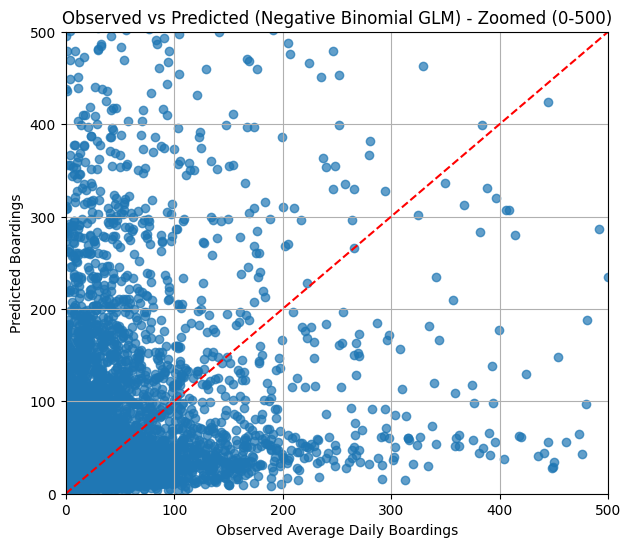

In [10]:
plt.figure(figsize=(7, 6))

plt.scatter(observed, predicted, alpha=0.7)

# perfect fit line
plt.plot([0, 500], [0, 500], color="red", linestyle="--")

plt.xlim(0, 500)
plt.ylim(0, 500)

plt.xlabel("Observed Average Daily Boardings")
plt.ylabel("Predicted Boardings")
plt.title("Observed vs Predicted (Negative Binomial GLM) - Zoomed (0-500)")
plt.grid(True)

plt.show()

### Saturday Model 

In [11]:
stop_route_df_selected_org = stop_route_df_saturday[
    stop_route_df_saturday['organization_name'].isin([
        'SamTrans',
        'Golden Gate Transit',
        'Long Beach Transit',
        'SDMTS',
        # 'Golden Gate Park Shuttle',
        'Fresno County',
        'San Francisco Bay Area Rapid Transit District',
        'Big Blue Bus',
        # 'Caltrain',
        'Culver City Bus',
        'Foothill Transit',
        # 'Riverside Transit',
        'Gold Coast Transit',
        'SacRT Bus',
        'Orange County Transportation Authority'
    ])
]

In [12]:
# Copy the dataset
df_saturday = stop_route_df_selected_org.copy()

y = df_saturday['average_daily_boardings']

X = df_saturday[['n_arrivals', 'n_routes',
        'land_use_index', 'workers_with_no_car_adj', 'poverty_pop_adj', 'disabled_pop_adj']]

# 4. Add intercept
X = sm.add_constant(X)

# Same X and y as  Poisson
nb_model_extended_final_saturday = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model_extended_final_saturday.summary())

                    Generalized Linear Model Regression Results                    
Dep. Variable:     average_daily_boardings   No. Observations:                 9051
Model:                                 GLM   Df Residuals:                     9044
Model Family:             NegativeBinomial   Df Model:                            6
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -34617.
Date:                     Thu, 04 Jun 2026   Deviance:                       16805.
Time:                             21:30:01   Pearson chi2:                 8.36e+04
No. Iterations:                         45   Pseudo R-squ. (CS):             0.8837
Covariance Type:                 nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

/home/jovyan/data-analyses/.venv/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### Sunday Model

In [13]:
# Copy the dataset
df_sunday = stop_route_df_sunday.copy()


y = df_sunday['average_daily_boardings']

X = df_sunday[['n_arrivals', 'n_routes',
        'land_use_index', 'workers_with_no_car_adj', 'poverty_pop_adj', 'disabled_pop_adj']]

# 4. Add intercept
X = sm.add_constant(X)

# Same X and y as  Poisson
nb_model_extended_final_sunday = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model_extended_final_sunday.summary())

                    Generalized Linear Model Regression Results                    
Dep. Variable:     average_daily_boardings   No. Observations:                12315
Model:                                 GLM   Df Residuals:                    12308
Model Family:             NegativeBinomial   Df Model:                            6
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -43820.
Date:                     Thu, 04 Jun 2026   Deviance:                       22018.
Time:                             21:30:06   Pearson chi2:                 1.64e+05
No. Iterations:                         33   Pseudo R-squ. (CS):             0.8900
Covariance Type:                 nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

/home/jovyan/data-analyses/.venv/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
